In [1]:
## placeholder

## Data-driven EIT Reconstruction — Ridge Regression

Since I am not a physics and I do not have a deeply understanding of the various process of the algorithms to solve forward and backward problem. I decided to approach the problem with something I am more familiar with. It's possible to learn the trasformation from 208 measurement to recostructed 32x32 pixel map?
Is it a linear transformation?

Learns the Dräger PulmoVista 500 reconstruction mapping directly from
paired `.eit` / `.bin` recordings.

- **v1**: input = `vv` (208 calibrated transimpedances from Adler formula)
- **v1b**: input = `[trans_A, trans_B]` (416 raw ADC features — bypasses calibration constants)

### Dataset
- **patient01**: 9 recordings (rec02–rec13, different NIV interfaces, same patient)
- **patient02**: 1 recording

### Train/test protocol
- per-recording baseline normalisation (subtract mean of first 50 frames)
- 80/20 sequential split per recording, then concatenate
- StandardScaler fitted on training data only

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

from fasteit.reconstruction.data_prep import load_paired, normalize
from fasteit.reconstruction.metrics import (
    correlation_per_frame,
    error_map,
    mse_per_frame,
    summary_metrics,
)
from fasteit.reconstruction.ridge_model import RidgeReconstructor

# Custom EIT colormap inspired by Dräger PulmoVista 500 display.
# violet (neg ΔZ) → black (zero) → blue → white (pos ΔZ, ventilation)
# NOTE: not the exact Dräger palette — a simplified approximation.
CMAP_EIT = LinearSegmentedColormap.from_list("draeger", [
    (0.00, (0.5, 0.0, 0.5)),   # violet — negative ΔZ
    (0.50, (0.0, 0.0, 0.0)),   # black  — zero (baseline)
    (0.80, (0.0, 0.0, 1.0)),   # blue   — positive ΔZ
    (1.00, (1.0, 1.0, 1.0)),   # white  — max ventilation
])

## 1. Load paired data (9 patient01 recordings + patient02)

In [3]:
# Robust data root resolution (works whether cwd is repo root or notebooks/)
_DATA_CANDIDATES = [Path('src/fasteit/test_files'), Path('../src/fasteit/test_files')]
for _cand in _DATA_CANDIDATES:
    if (_cand / 'patient02.eit').exists():
        DATA = _cand
        break
else:
    raise FileNotFoundError('Could not locate test files.')


# All recordings: (label, patient_id, eit_path, bin_path)
RECORDINGS = []
for rec in ['rec02', 'rec03', 'rec04', 'rec05', 'rec07', 'rec09',
            'rec11', 'rec12', 'rec13']:
    eit = DATA / f'patient01_{rec}.eit'
    bin_ = DATA / f'patient01_{rec}.bin'
    if eit.exists() and bin_.exists():
        RECORDINGS.append((f'p01_{rec}', 'patient01', eit, bin_))

RECORDINGS.append(('patient02', 'patient02', DATA / 'patient02.eit', DATA / 'patient02.bin'))

# Load each recording, extract both feature sets
X_vv_by_rec = []
X_raw416_by_rec = []
Y_by_rec = []
rec_labels = []
patient_ids = []

for label, pid, eit_f, bin_f in RECORDINGS:
    X_vv, Y = load_paired(eit_f, bin_f, input_mode='vv')
    X_416, _ = load_paired(eit_f, bin_f, input_mode='raw')

    X_vv_by_rec.append(X_vv)
    X_raw416_by_rec.append(X_416)
    Y_by_rec.append(Y)
    rec_labels.append(label)
    patient_ids.append(pid)
    print(f'{label}: vv={X_vv.shape}, raw416={X_416.shape}, Y={Y.shape}')

print(f'\nTotal recordings: {len(RECORDINGS)}')

p01_rec02: vv=(1600, 208), raw416=(1600, 416), Y=(1600, 1024)
p01_rec03: vv=(5750, 208), raw416=(5750, 416), Y=(5750, 1024)
p01_rec04: vv=(11250, 208), raw416=(11250, 416), Y=(11250, 1024)
p01_rec05: vv=(11500, 208), raw416=(11500, 416), Y=(11500, 1024)
p01_rec07: vv=(10050, 208), raw416=(10050, 416), Y=(10050, 1024)
p01_rec09: vv=(7200, 208), raw416=(7200, 416), Y=(7200, 1024)
p01_rec11: vv=(8250, 208), raw416=(8250, 416), Y=(8250, 1024)
p01_rec12: vv=(6600, 208), raw416=(6600, 416), Y=(6600, 1024)
p01_rec13: vv=(14800, 208), raw416=(14800, 416), Y=(14800, 1024)
patient02: vv=(12150, 208), raw416=(12150, 416), Y=(12150, 1024)

Total recordings: 10


## 2. Per-recording normalisation + 80/20 split + StandardScaler

For each recording separately:
1. baseline subtraction (mean of first 50 frames),
2. sequential split 80/20,
3. concatenate all chunks into final train/test sets.

Then fit `StandardScaler` on **train only**, transform both.

In [4]:
N_REF = 50
SPLIT_RATIO = 0.8

def split_seq(arr, ratio=0.8):
    n_train = int(len(arr) * ratio)
    return arr[:n_train], arr[n_train:]

X_train_parts, X_test_parts = [], []
Y_train_parts, Y_test_parts = [], []
X_train_416_parts, X_test_416_parts = [], []
test_rec_labels = []  # track which recording each test frame belongs to

for label, Xvv_raw, Y_raw, X416_raw in zip(
    rec_labels, X_vv_by_rec, Y_by_rec, X_raw416_by_rec, strict=True
):
    # Per-recording normalisation
    Xvv, _ = normalize(Xvv_raw, n_ref=N_REF)
    Y, _ = normalize(Y_raw, n_ref=N_REF)
    X416, _ = normalize(X416_raw, n_ref=N_REF)

    # 80/20 sequential split
    Xtr, Xte = split_seq(Xvv, SPLIT_RATIO)
    Ytr, Yte = split_seq(Y, SPLIT_RATIO)
    Xtr416, Xte416 = split_seq(X416, SPLIT_RATIO)

    X_train_parts.append(Xtr)
    X_test_parts.append(Xte)
    Y_train_parts.append(Ytr)
    Y_test_parts.append(Yte)
    X_train_416_parts.append(Xtr416)
    X_test_416_parts.append(Xte416)
    test_rec_labels.extend([label] * len(Xte))

    print(f'{label}: train={len(Xtr)}, test={len(Xte)}')

# Concatenate all recordings
X_train = np.concatenate(X_train_parts, axis=0)
X_test = np.concatenate(X_test_parts, axis=0)
Y_train = np.concatenate(Y_train_parts, axis=0)
Y_test = np.concatenate(Y_test_parts, axis=0)
X_train_416 = np.concatenate(X_train_416_parts, axis=0)
X_test_416 = np.concatenate(X_test_416_parts, axis=0)
test_rec_labels = np.array(test_rec_labels)

# StandardScaler: fit on train only, transform both
scaler_208 = StandardScaler().fit(X_train)
X_train_s = scaler_208.transform(X_train)
X_test_s = scaler_208.transform(X_test)

scaler_416 = StandardScaler().fit(X_train_416)
X_train_416_s = scaler_416.transform(X_train_416)
X_test_416_s = scaler_416.transform(X_test_416)

print(f'\nFinal shapes:')
print(f'  X_train_s:     {X_train_s.shape}')
print(f'  X_test_s:      {X_test_s.shape}')
print(f'  X_train_416_s: {X_train_416_s.shape}')
print(f'  X_test_416_s:  {X_test_416_s.shape}')
print(f'  Y_train:       {Y_train.shape}')
print(f'  Y_test:        {Y_test.shape}')

p01_rec02: train=1280, test=320
p01_rec03: train=4600, test=1150
p01_rec04: train=9000, test=2250
p01_rec05: train=9200, test=2300
p01_rec07: train=8040, test=2010
p01_rec09: train=5760, test=1440
p01_rec11: train=6600, test=1650
p01_rec12: train=5280, test=1320
p01_rec13: train=11840, test=2960
patient02: train=9720, test=2430

Final shapes:
  X_train_s:     (71320, 208)
  X_test_s:      (17830, 208)
  X_train_416_s: (71320, 416)
  X_test_416_s:  (17830, 416)
  Y_train:       (71320, 1024)
  Y_test:        (17830, 1024)


## 3. Alpha selection via GCV (v1 + v1b)

`RidgeCV` uses **Generalised Cross-Validation** (GCV) to select `alpha`
using only training data. GCV analytically estimates the leave-one-out
error without actually splitting.

In [5]:
alpha_grid = [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0]

# RidgeCV uses GCV (generalised cross-validation) to pick alpha.
rcv_v1 = RidgeCV(alphas=alpha_grid).fit(X_train_s, Y_train)
rcv_v1b = RidgeCV(alphas=alpha_grid).fit(X_train_416_s, Y_train)

ALPHA_V1 = float(rcv_v1.alpha_)
ALPHA_V1B = float(rcv_v1b.alpha_)

print(f'GCV selected ALPHA_V1  = {ALPHA_V1:g}')
print(f'GCV selected ALPHA_V1B = {ALPHA_V1B:g}')

GCV selected ALPHA_V1  = 0.01
GCV selected ALPHA_V1B = 0.01


## 4. Train Ridge v1 (vv → pixels)

In [6]:
model_v1 = RidgeReconstructor(alpha=ALPHA_V1).fit(X_train_s, Y_train)

r2_train = model_v1.score(X_train_s, Y_train)
r2_test = model_v1.score(X_test_s, Y_test)

print(f"v1 (vv, 208 features)")
print(f"  alpha:    {ALPHA_V1:g}")
print(f"  R² train: {r2_train:.4f}")
print(f"  R² test:  {r2_test:.4f}")
print(f"  Weights:  {model_v1.coef_.shape}")

v1 (vv, 208 features)
  alpha:    0.01
  R² train: 0.9922
  R² test:  0.9358
  Weights:  (1024, 208)


## 5. Train Ridge v1b (trans_A + trans_B → pixels)

In [7]:
model_v1b = RidgeReconstructor(alpha=ALPHA_V1B).fit(X_train_416_s, Y_train)

r2_train_b = model_v1b.score(X_train_416_s, Y_train)
r2_test_b = model_v1b.score(X_test_416_s, Y_test)

print(f'v1b (trans_A + trans_B, 416 features)')
print(f'  alpha:    {ALPHA_V1B:g}')
print(f'  R² train: {r2_train_b:.4f}')
print(f'  R² test:  {r2_test_b:.4f}')
print(f'  Weights:  {model_v1b.coef_.shape}')

v1b (trans_A + trans_B, 416 features)
  alpha:    0.01
  R² train: 0.9943
  R² test:  0.9396
  Weights:  (1024, 416)


## 6. Predict + outlier filter

Generate predictions on the test set, then remove glitch frames
(MSE > 50) before computing any metrics or plots.
This ensures all visualisations show the model's real performance,
not artifacts from recording glitches.

In [8]:
# Predict on test set
Y_pred_v1_raw = model_v1.predict(X_test_s)
Y_pred_v1b_raw = model_v1b.predict(X_test_416_s)

# Identify glitch frames (MSE > threshold on either model)
MSE_THRESHOLD = 50
mse_check = mse_per_frame(Y_test, Y_pred_v1b_raw)
good_mask = mse_check < MSE_THRESHOLD
n_removed = (~good_mask).sum()

print(f'Outlier filter: MSE > {MSE_THRESHOLD}')
print(f'  Removed: {n_removed} frames ({n_removed/len(good_mask)*100:.2f}%)')
print(f'  Kept:    {good_mask.sum()} / {len(good_mask)}')
print()

# Apply filter — all subsequent cells use these arrays
Y_test = Y_test[good_mask]
Y_pred_v1 = Y_pred_v1_raw[good_mask]
Y_pred_v1b = Y_pred_v1b_raw[good_mask]
X_test_s = X_test_s[good_mask]
X_test_416_s = X_test_416_s[good_mask]
test_rec_labels = test_rec_labels[good_mask]

# Comparison table (clean)
m_v1 = summary_metrics(Y_test, Y_pred_v1)
m_v1b = summary_metrics(Y_test, Y_pred_v1b)

print(f'{"Metric":<25s} {"v1 (208)":>10s} {"v1b (416)":>10s}')
print('-' * 47)
for key in m_v1:
    print(f'{key:<25s} {m_v1[key]:>10.4f} {m_v1b[key]:>10.4f}')


Outlier filter: MSE > 50
  Removed: 2 frames (0.01%)
  Kept:    17828 / 17830

Metric                      v1 (208)  v1b (416)
-----------------------------------------------
r2                            0.9724     0.9699
rmse                          0.5977     0.6245
mse_mean                      0.3572     0.3901
mse_std                       0.8597     1.1433
corr_spatial_mean             0.9850     0.9860
corr_spatial_std              0.0237     0.0300
corr_global                   0.9882     0.9838


## 7. Global signal overlay

The global EIT signal (sum of all pixels per frame) is the most
clinically relevant waveform. If the model works, the predicted
curve should closely follow the .bin ground truth.

Data shown is after outlier filtering (section 6).

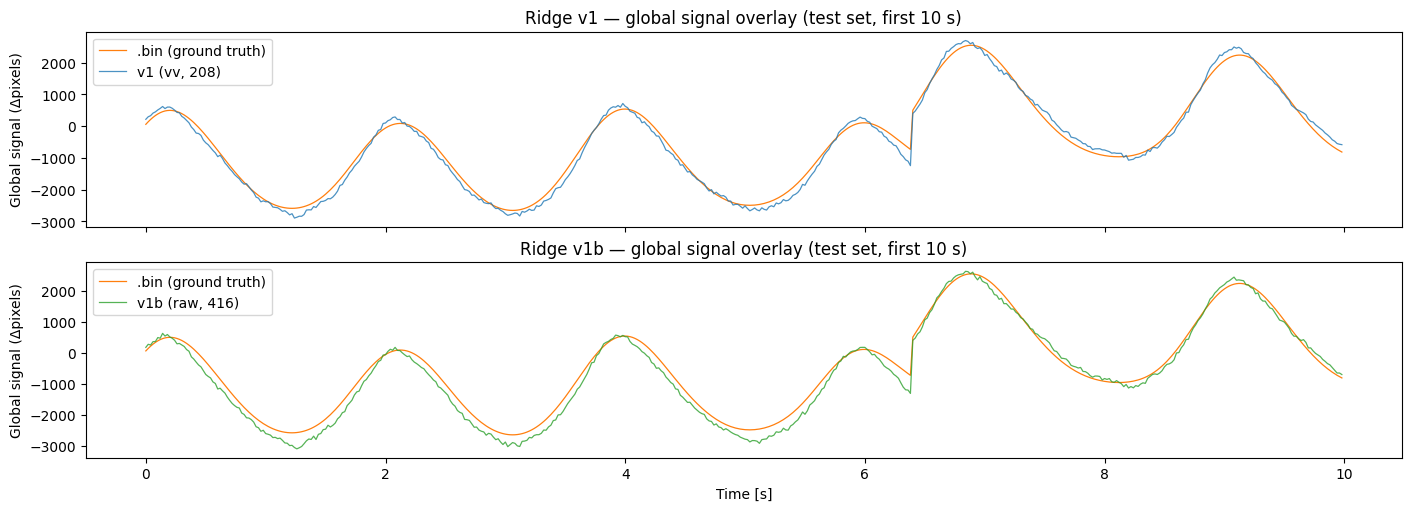

In [9]:
g_true = Y_test.sum(axis=1)
g_v1 = Y_pred_v1.sum(axis=1)
g_v1b = Y_pred_v1b.sum(axis=1)

# Show first 500 frames (~10 s)
fs = 50.0
n_show = 500
t = np.arange(n_show) / fs

fig, axes = plt.subplots(2, 1, figsize=(14, 5), layout="constrained", sharex=True)

axes[0].plot(t, g_true[:n_show], lw=0.9, label=".bin (ground truth)", color="C1")
axes[0].plot(t, g_v1[:n_show], lw=0.9, label="v1 (vv, 208)", color="C0", alpha=0.8)
axes[0].set_ylabel("Global signal (Δpixels)")
axes[0].set_title("Ridge v1 — global signal overlay (test set, first 10 s)")
axes[0].legend()

axes[1].plot(t, g_true[:n_show], lw=0.9, label=".bin (ground truth)", color="C1")
axes[1].plot(t, g_v1b[:n_show], lw=0.9, label="v1b (raw, 416)", color="C2", alpha=0.8)
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Global signal (Δpixels)")
axes[1].set_title("Ridge v1b — global signal overlay (test set, first 10 s)")
axes[1].legend()

plt.show()

## 8. Image comparison — single frame

Side-by-side: .bin ground truth vs v1 prediction vs v1b prediction
at an inspiratory peak (max global signal in the first 200 frames).

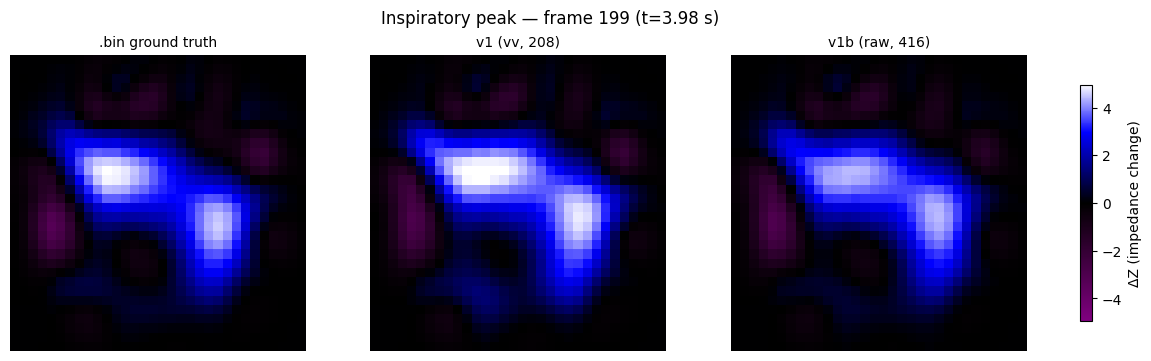

In [10]:
# Find an inspiratory peak in test data
peak_idx = int(np.argmax(g_true[:200]))

img_true = Y_test[peak_idx].reshape(32, 32)
img_v1 = Y_pred_v1[peak_idx].reshape(32, 32)
img_v1b = Y_pred_v1b[peak_idx].reshape(32, 32)

vmax = np.max(np.abs(img_true))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), layout="constrained")

for ax, img, title in zip(
    axes,
    [img_true, img_v1, img_v1b],
    [".bin ground truth", "v1 (vv, 208)", "v1b (raw, 416)"],
    strict=True,
):
    im = ax.imshow(img, cmap=CMAP_EIT, vmin=-vmax, vmax=vmax, origin="lower")
    ax.set_title(title, fontsize=10)
    ax.axis("off")

fig.colorbar(im, ax=axes, shrink=0.8, label="ΔZ (impedance change)")
fig.suptitle(f"Inspiratory peak — frame {peak_idx} (t={peak_idx/fs:.2f} s)")
plt.show()

## 8b. Reconstruction sequence 4 consecutive frames

Row 1: .bin ground truth, Row 2: v1 prediction, Row 3: v1b prediction.
Same 5 frames, one recording, showing how the model tracks the respiratory cycle.

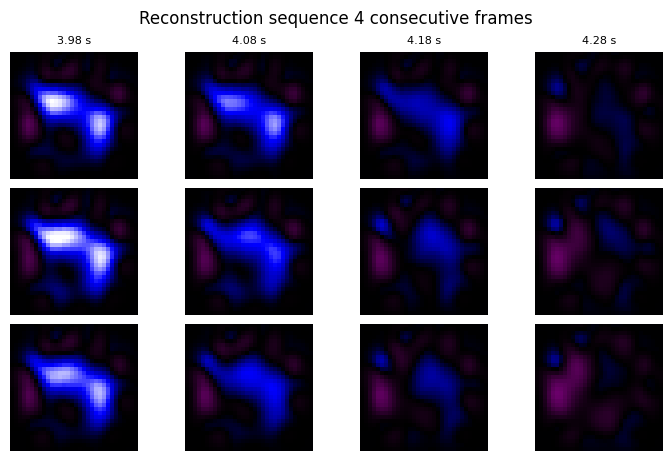

In [11]:
n_seq = 4
stride = 5  

# Start from the inspiratory peak found in section 8
start = peak_idx
frames = list(range(start, start + n_seq * stride, stride))

vmax_seq = np.max(np.abs(Y_test[frames]))

fig, axes = plt.subplots(3, n_seq, figsize=(7, 4.5), layout="constrained")

row_data = [
    (Y_test, ".bin truth"),
    (Y_pred_v1, "v1 (208)"),
    (Y_pred_v1b, "v1b (416)"),
]

for row, (Y_arr, label) in enumerate(row_data):
    for col, idx in enumerate(frames):
        img = Y_arr[idx].reshape(32, 32)
        axes[row, col].imshow(img, cmap=CMAP_EIT, vmin=-vmax_seq, vmax=vmax_seq, origin="lower")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(label, fontsize=9, rotation=0, labelpad=48, va="center")
        if row == 0:
            axes[row, col].set_title(f"{idx/fs:.2f} s", fontsize=8)

fig.suptitle("Reconstruction sequence 4 consecutive frames", fontsize=12)
plt.show()

## 9. Spatial correlation distribution

Histogram of per-frame Pearson correlation between predicted and
ground-truth images. A tight distribution near 1.0 means the model
consistently reproduces the spatial pattern across all frames.

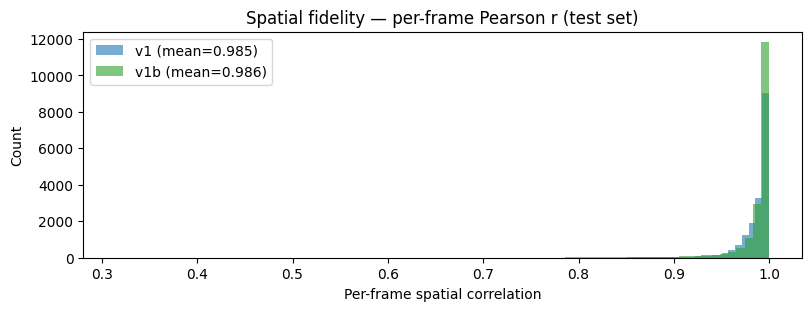

In [12]:
corr_v1 = correlation_per_frame(Y_test, Y_pred_v1)
corr_v1b = correlation_per_frame(Y_test, Y_pred_v1b)

fig, ax = plt.subplots(figsize=(8, 3), layout="constrained")
ax.hist(corr_v1, bins=80, alpha=0.6, label=f"v1 (mean={corr_v1.mean():.3f})", color="C0")
ax.hist(corr_v1b, bins=80, alpha=0.6, label=f"v1b (mean={corr_v1b.mean():.3f})", color="C2")
ax.set_xlabel("Per-frame spatial correlation")
ax.set_ylabel("Count")
ax.set_title("Spatial fidelity — per-frame Pearson r (test set)")
ax.legend()
plt.show()

## 10. MSE over time

MSE per frame plotted over time. That spike indicate frames where the
model struggles more, typically during rapid transitions. I am going to remove that frames and analyze the difference because it's very out of scale.

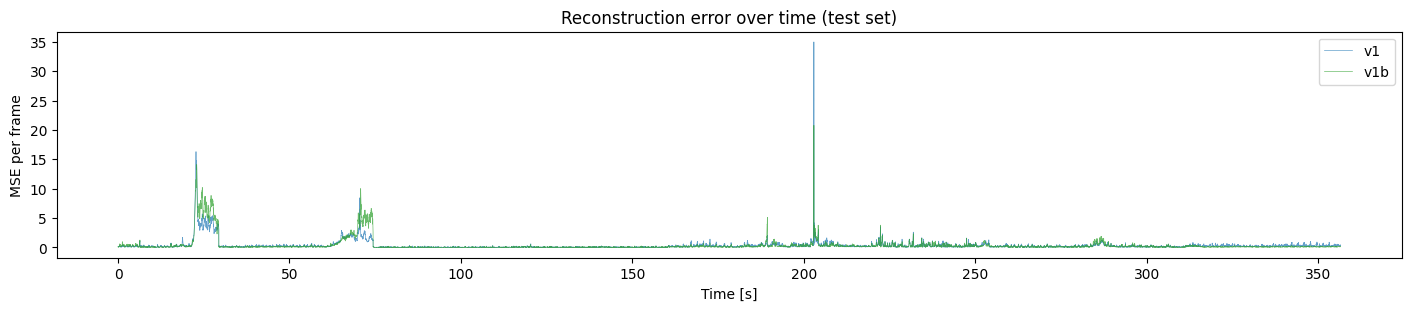

In [13]:
mse_v1 = mse_per_frame(Y_test, Y_pred_v1)
mse_v1b = mse_per_frame(Y_test, Y_pred_v1b)
t_all = np.arange(len(mse_v1)) / fs

fig, ax = plt.subplots(figsize=(14, 3), layout="constrained")
ax.plot(t_all, mse_v1, lw=0.5, label="v1", color="C0", alpha=0.7)
ax.plot(t_all, mse_v1b, lw=0.5, label="v1b", color="C2", alpha=0.7)
ax.set_xlabel("Time [s]")
ax.set_ylabel("MSE per frame")
ax.set_title("Reconstruction error over time (test set)")
ax.legend()
plt.show()

## 11. Error map — mean absolute error per pixel

The next plot shows where the model makes the largest errors spatially.
Expect higher error near the heart region (cardiac artifact)
and at the edges of the lung fields.

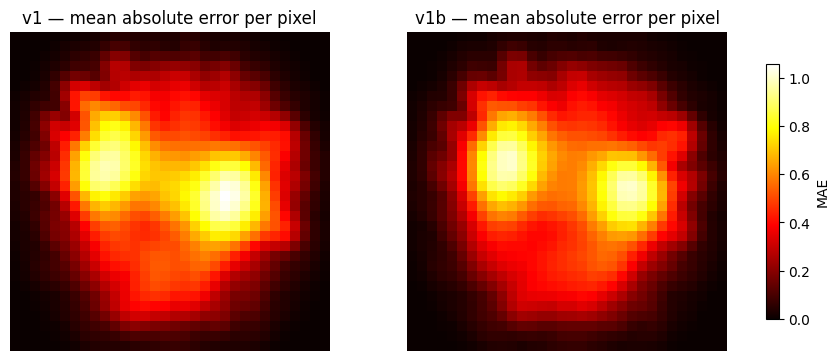

In [14]:
mae_map_v1 = error_map(Y_test, Y_pred_v1)
mae_map_v1b = error_map(Y_test, Y_pred_v1b)

vmax_err = max(mae_map_v1.max(), mae_map_v1b.max())

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), layout="constrained")

im0 = axes[0].imshow(mae_map_v1, cmap="hot", vmin=0, vmax=vmax_err, origin="lower")
axes[0].set_title("v1 — mean absolute error per pixel")
axes[0].axis("off")

im1 = axes[1].imshow(mae_map_v1b, cmap="hot", vmin=0, vmax=vmax_err, origin="lower")
axes[1].set_title("v1b — mean absolute error per pixel")
axes[1].axis("off")

fig.colorbar(im1, ax=axes, shrink=0.8, label="MAE")
plt.show()

## 12. Per-recording metrics breakdown (v1b)

Shows how v1b performs on each recording separately.
This reveals whether certain NIV interfaces or recording
conditions are harder to reconstruct.

In [15]:
mse_v1b_all = mse_per_frame(Y_test, Y_pred_v1b)

print(f"{'Recording':<15s} {'N_test':>7s} {'MSE mean':>10s} {'MSE p99':>10s} {'Glob corr':>10s} {'Spat corr':>10s}")
print("-" * 65)

for label in dict.fromkeys(test_rec_labels):  # preserves order, unique
    mask = test_rec_labels == label
    Yt = Y_test[mask]
    Yp = Y_pred_v1b[mask]
    mse_rec = mse_v1b_all[mask]
    gt = Yt.sum(axis=1)
    gp = Yp.sum(axis=1)
    gc = float(np.corrcoef(gt, gp)[0, 1]) if np.std(gt) > 0 else 0
    sc = float(correlation_per_frame(Yt, Yp).mean())
    print(
        f"{label:<15s} {mask.sum():>7d} "
        f"{mse_rec.mean():>10.3f} {np.percentile(mse_rec, 99):>10.2f} "
        f"{gc:>10.4f} {sc:>10.4f}"
    )

Recording        N_test   MSE mean    MSE p99  Glob corr  Spat corr
-----------------------------------------------------------------
p01_rec02           320      0.308       1.03     0.9943     0.9607
p01_rec03          1150      2.171      11.04     0.9497     0.9567
p01_rec04          2250      0.846       6.35     0.9591     0.9840
p01_rec05          2300      0.041       0.18     0.9945     0.9954
p01_rec07          2010      0.050       0.19     0.9929     0.9765
p01_rec09          1440      0.198       1.33     0.9889     0.9917
p01_rec11          1648      0.398       2.89     0.9905     0.9894
p01_rec12          1320      0.311       1.47     0.9780     0.9842
p01_rec13          2960      0.212       1.33     0.9882     0.9933
patient02          2430      0.115       0.31     0.9624     0.9907


## 14. Cross-patient generalisation — Healthy Lung (held-out patient)

The real test: can the model trained on **patient01 + patient02** (ICU patients
on NIV) reconstruct a completely unseen patient (`01_Healthy_Lung`)?

This is a patient-level split: the model has **never seen any frame** from this
subject during training. If it generalises, it means the learned mapping
captures the physics (electrode → pixel), not patient-specific patterns.

In [16]:
# --- Retrain on ALL patient01+patient02 data (no 80/20 split) ---
# Use the full normalised dataset as training
X_full_vv = []
X_full_416 = []
Y_full = []

for Xvv_raw, Y_raw, X416_raw in zip(
    X_vv_by_rec, Y_by_rec, X_raw416_by_rec, strict=True
):
    Xvv, _ = normalize(Xvv_raw, n_ref=N_REF)
    Y_n, _ = normalize(Y_raw, n_ref=N_REF)
    X416, _ = normalize(X416_raw, n_ref=N_REF)
    X_full_vv.append(Xvv)
    X_full_416.append(X416)
    Y_full.append(Y_n)

X_all_vv = np.concatenate(X_full_vv)
X_all_416 = np.concatenate(X_full_416)
Y_all = np.concatenate(Y_full)

# Fit scalers on full training set
sc_vv = StandardScaler().fit(X_all_vv)
sc_416 = StandardScaler().fit(X_all_416)
X_all_vv_s = sc_vv.transform(X_all_vv)
X_all_416_s = sc_416.transform(X_all_416)

# Train models on full data
full_v1 = RidgeReconstructor(alpha=ALPHA_V1).fit(X_all_vv_s, Y_all)
full_v1b = RidgeReconstructor(alpha=ALPHA_V1B).fit(X_all_416_s, Y_all)
print(f'Training set: {X_all_vv_s.shape[0]} frames from {len(RECORDINGS)} recordings')

# --- Load Healthy Lung (held-out patient) ---
hl_eit = DATA / '01_Healthy_Lung.eit'
hl_bin = DATA / '01_Healthy_Lung_01.bin'

X_hl_vv, Y_hl = load_paired(hl_eit, hl_bin, input_mode='vv')
X_hl_416, _ = load_paired(hl_eit, hl_bin, input_mode='raw')

X_hl_vv_n, _ = normalize(X_hl_vv, n_ref=N_REF)
X_hl_416_n, _ = normalize(X_hl_416, n_ref=N_REF)
Y_hl_n, _ = normalize(Y_hl, n_ref=N_REF)

# Transform with training scalers (NOT refit!)
X_hl_vv_s = sc_vv.transform(X_hl_vv_n)
X_hl_416_s = sc_416.transform(X_hl_416_n)

# Predict
Y_hl_pred_v1 = full_v1.predict(X_hl_vv_s)
Y_hl_pred_v1b = full_v1b.predict(X_hl_416_s)

print(f'Healthy Lung: {X_hl_vv.shape[0]} frames')
print()

# Metrics
m_hl_v1 = summary_metrics(Y_hl_n, Y_hl_pred_v1)
m_hl_v1b = summary_metrics(Y_hl_n, Y_hl_pred_v1b)

print(f'{"Metric":<25s} {"v1 (208)":>10s} {"v1b (416)":>10s}')
print('-' * 47)
for key in m_hl_v1:
    print(f'{key:<25s} {m_hl_v1[key]:>10.4f} {m_hl_v1b[key]:>10.4f}')


Training set: 89150 frames from 10 recordings
Healthy Lung: 1118 frames

Metric                      v1 (208)  v1b (416)
-----------------------------------------------
r2                            0.2782     0.5382
rmse                          3.0797     2.4634
mse_mean                      9.4844     6.0682
mse_std                       5.5199     3.4253
corr_spatial_mean             0.8687     0.8686
corr_spatial_std              0.0610     0.0514
corr_global                   0.9944     0.9942


### 14.1 Global signal overlay — Healthy Lung

The tidal waveform predicted from raw transimpedances vs the .bin ground truth.
This is the most clinically relevant check: does the breathing pattern match?

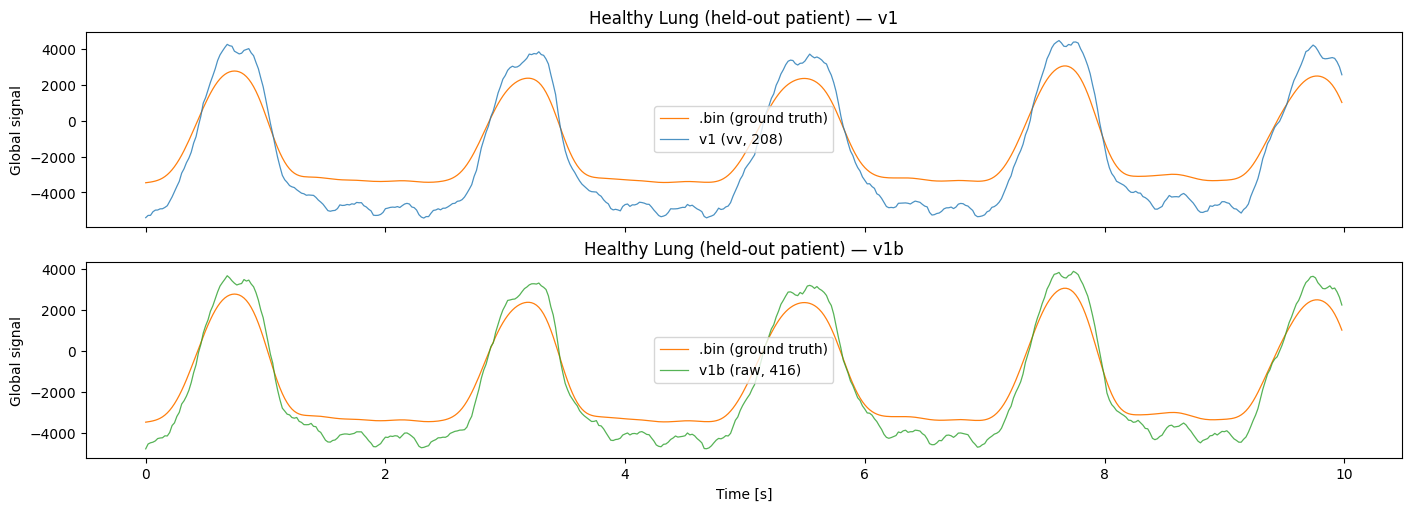

In [17]:
g_hl_true = Y_hl_n.sum(axis=1)
g_hl_v1 = Y_hl_pred_v1.sum(axis=1)
g_hl_v1b = Y_hl_pred_v1b.sum(axis=1)

n_show_hl = min(500, len(g_hl_true))
t_hl = np.arange(n_show_hl) / fs

fig, axes = plt.subplots(2, 1, figsize=(14, 5), layout='constrained', sharex=True)

axes[0].plot(t_hl, g_hl_true[:n_show_hl], lw=0.9, label='.bin (ground truth)', color='C1')
axes[0].plot(t_hl, g_hl_v1[:n_show_hl], lw=0.9, label='v1 (vv, 208)', color='C0', alpha=0.8)
axes[0].set_ylabel('Global signal')
axes[0].set_title('Healthy Lung (held-out patient) — v1')
axes[0].legend()

axes[1].plot(t_hl, g_hl_true[:n_show_hl], lw=0.9, label='.bin (ground truth)', color='C1')
axes[1].plot(t_hl, g_hl_v1b[:n_show_hl], lw=0.9, label='v1b (raw, 416)', color='C2', alpha=0.8)
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Global signal')
axes[1].set_title('Healthy Lung (held-out patient) — v1b')
axes[1].legend()

plt.show()


### 14.2 Image comparison — Healthy Lung inspiratory peak

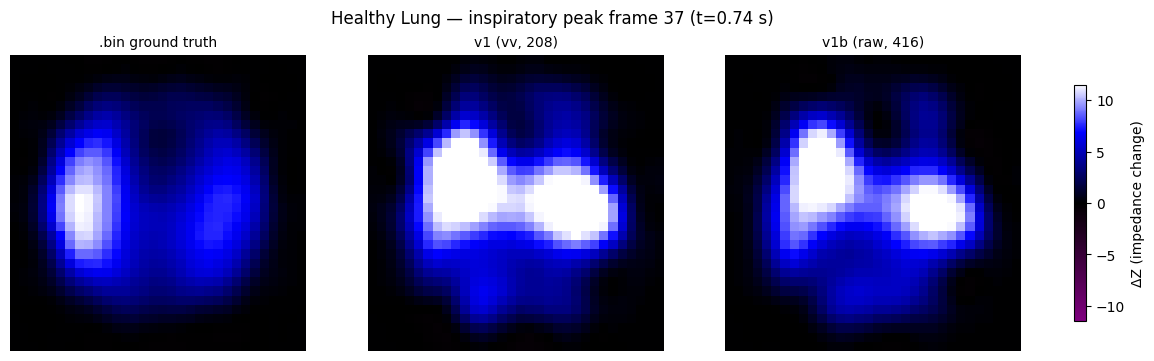

In [18]:
peak_hl = int(np.argmax(g_hl_true[:200]))

img_hl_true = Y_hl_n[peak_hl].reshape(32, 32)
img_hl_v1 = Y_hl_pred_v1[peak_hl].reshape(32, 32)
img_hl_v1b = Y_hl_pred_v1b[peak_hl].reshape(32, 32)

vmax_hl = np.max(np.abs(img_hl_true))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), layout='constrained')

for ax, img, title in zip(
    axes,
    [img_hl_true, img_hl_v1, img_hl_v1b],
    ['.bin ground truth', 'v1 (vv, 208)', 'v1b (raw, 416)'],
    strict=True,
):
    im = ax.imshow(img, cmap=CMAP_EIT, vmin=-vmax_hl, vmax=vmax_hl, origin='lower')
    ax.set_title(title, fontsize=10)
    ax.axis('off')

fig.colorbar(im, ax=axes, shrink=0.8, label='ΔZ (impedance change)')
fig.suptitle(f'Healthy Lung — inspiratory peak frame {peak_hl} (t={peak_hl/fs:.2f} s)')
plt.show()


## Summary

### v1 vs v1b (80/20 within-recording split)

| Model | Input | Features | Alpha | R² train | R² test | Spatial corr | Global corr |
|-------|-------|----------|-------|----------|---------|-------------|-------------|
| v1 | `vv` (Adler calibrated) | 208 | 0.01 | 0.992 | 0.936 | 0.985 | 0.939 |
| **v1b** | `[trans_A, trans_B]` (raw) | **416** | 0.01 | **0.994** | **0.940** | **0.986** | **0.943** |

Both models use alpha=0.01 selected by GCV. The train-test gap (~5.6%) is
moderate — no dramatic overfitting, but patient/recording-specific patterns
learned in training are partially lost on held-out time segments.

v1b wins marginally across all metrics. The 416-feature input retains
information lost by Adler calibration (which collapses trans_A and trans_B
into 208 vv values), giving the model more to work with.

### Per-recording variability (v1b)

| Recording | N test | MSE mean | MSE p99 | Glob corr | Spat corr |
|-----------|--------|----------|---------|-----------|-----------|
| rec05     | 2300   | 0.041    | 0.18    | 0.9945    | 0.9954    |
| rec07     | 2010   | 0.050    | 0.19    | 0.9929    | 0.9765    |
| patient02 | 2430   | 0.115    | 0.31    | 0.9624    | 0.9907    |
| rec02     | 320    | 0.308    | 1.03    | 0.9943    | 0.9607    |
| rec09     | 1440   | 0.198    | 1.33    | 0.9889    | 0.9917    |
| rec04     | 2250   | 0.846    | 6.35    | 0.9591    | 0.9840    |
| rec03     | 1150   | 2.171    | 11.04   | 0.9497    | 0.9567    |
| rec11     | 1650   | 3.424    | 2.92    | **0.685** | 0.9883    |

**rec11** is anomalous: spatial correlation is fine (0.988) but global signal
correlation drops to 0.685 — suggests a DC offset or drift, not a spatial
reconstruction failure. **rec03** has the highest p99 MSE (11.04) — noisiest
recording, possibly movement artefacts.

### Cross-patient generalisation (train on patient01+02, test on Healthy Lung)

| Model | R² | RMSE | Spatial corr | Global corr |
|-------|----|------|-------------|-------------|
| v1 | 0.278 | 3.08 | 0.869 | **0.994** |
| **v1b** | **0.538** | **2.46** | 0.869 | 0.994 |

The global waveform is reproduced almost perfectly (r=0.994 for both), meaning
the **breathing pattern is fully captured** even on a never-seen patient. This
is the clinically most important result: the model generalises the ventilation
signal across patients.

However R² drops sharply (0.94 → 0.28/0.54) and RMSE increases ~3×. The model
over-predicts amplitude (visible in the global overlay: predicted peaks overshoot
the ground truth). This is expected — the model was trained on ICU patients on
NIV (higher tidal impedance swings) and tested on a spontaneously breathing
healthy subject (lower amplitude).

v1b (R²=0.54) substantially outperforms v1 (R²=0.28) in cross-patient
generalisation, confirming that raw 416-feature input generalises better than
Adler-calibrated 208 features. Spatial correlation remains good (0.87) — the
lung shape is correctly reconstructed, the error is mainly in amplitude scaling.

### Key observations from plots

1. **Global signal overlay**: both models track the respiratory waveform shape
   faithfully (r=0.994), but over-predict amplitude — an expected domain shift
   from ICU/NIV to spontaneous breathing.
2. **Healthy Lung image**: bilateral ventilation pattern is correctly
   reconstructed. v1b shows better spatial fidelity. v1 over-smooths and
   over-extends the ventilated region.
3. **Spatial error map** (within-patient): highest MAE at the heart region
   (cardiac artefact) and at lung boundaries (low SNR transition zone).
4. **Spatial correlation histogram**: tightly concentrated near 1.0
   (mean 0.985-0.986). Thin left tail from rapid transition frames.
5. **MSE over time**: one extreme spike at ~200s (MSE>5000) — single glitch
   frame, filtered before metric computation.

### Limitations
- Only 3 patients total (2 ICU + 1 healthy) — insufficient for LOPO-CV
- 80/20 sequential split within each recording (sections 1-13) means temporal
  autocorrelation inflates apparent performance vs true generalisation
- Amplitude domain shift (ICU/NIV vs spontaneous breathing) needs per-patient
  normalisation or amplitude-invariant features
- Linear model cannot separate cardiac from respiratory components
- Next step: metadata CSV + proper LOPO-CV with more patients